In [1]:
from google.colab import drive

drive.mount('/content/drive')

import os
plant_village_path = '/content/drive/MyDrive/PlantVillage'

Mounted at /content/drive
成功找到資料夾：/content/drive/MyDrive/PlantVillage


In [5]:
import sys
!{sys.executable} -m pip install split-folders

In [6]:
import os
import shutil
import splitfolders

input_folder = plant_village_path
output_folder = '/content/dataset_split'

if os.path.exists(output_folder):
    print(f"正在清理舊的輸出資料夾: {output_folder}...")
    shutil.rmtree(output_folder)

# 執行資料切分：Train (80%), Val (10%), Test (10%)
# 使用 seed=42 確保每次切分結果一致
splitfolders.ratio(input_folder,
                   output=output_folder,
                   seed=42,
                   ratio=(.8, .1, .1),
                   group_prefix=None,
                   move=False)

summary = {}
total_count = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_folder, split)
    count = sum([len(files) for r, d, files in os.walk(split_path) if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files)])
    summary[split] = count
    total_count += count
    print(f" - {split} 集合: {count} 張圖片")

print(f"\n總計切分圖片數: {total_count}")

正在開始重新切分資料...


Copying files: 20639 files [09:36, 35.77 files/s] 


資料切分完畢！開始計算各資料集數量：
 - train 集合: 16505 張圖片
 - val 集合: 2058 張圖片
 - test 集合: 2076 張圖片

總計切分圖片數: 20639


In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
from tqdm import tqdm

IMG_SIZE = (299, 299)
BATCH_SIZE = 64
NUM_WORKERS = 2

base_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(output_folder, 'train'), base_transforms),
    'val': datasets.ImageFolder(os.path.join(output_folder, 'val'), base_transforms),
    'test': datasets.ImageFolder(os.path.join(output_folder, 'test'), base_transforms)
}

# 計算訓練集 Mean 與 Std
temp_loader = DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images = 0
    for images, _ in tqdm(loader, desc='重新計算高解析度資料統計'):
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_samples
    return mean / total_images, std / total_images

mean, std = get_mean_and_std(temp_loader)

# 定義最終轉換流程
final_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 更新所有資料集的 transform
for phase in ['train', 'val', 'test']:
    image_datasets[phase].transform = final_transforms

# 建立最終 DataLoaders
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
}

print(f"\n解析度已更新為: {IMG_SIZE}, Batch Size: {BATCH_SIZE}")

正在計算高解析度資料的 Normalize 參數...


重新計算高解析度資料統計: 100%|██████████| 258/258 [01:15<00:00,  3.39it/s]


解析度已更新為: (299, 299), Batch Size: 64


In [16]:
# 檢查一個 batch 的數據形狀
inputs, classes = next(iter(dataloaders['train']))
print(f"Batch 數據形狀: {inputs.shape}  # [Batch, Channels, Height, Width]")
print(f"Batch 標籤數量: {len(classes)}")

Batch 數據形狀: torch.Size([64, 3, 299, 299])  # [Batch, Channels, Height, Width]
Batch 標籤數量: 64
DataLoaders 已就緒！


In [17]:
import torch.nn as nn
from torchvision import models

# 取得類別數量
num_classes = len(image_datasets['train'].classes)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"正在載入預訓練的 ResNet-18 模型... (目標類別數: {num_classes})")

# 載入預訓練模型 (ResNet18)
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 凍結所有模型參數
for param in model_ft.parameters():
    param.requires_grad = False

# 修改最後的全連接層 (Fully Connected Layer)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

# 將模型搬移至 GPU
model_ft = model_ft.to(device)

print(model_ft.fc)

正在載入預訓練的 ResNet-18 模型... (目標類別數: 15)
使用設備: cuda:0
模型定義完成！
Linear(in_features=512, out_features=15, bias=True)


In [18]:
import torch.optim as optim

# 設定損失函數
criterion = nn.CrossEntropyLoss()

# 設定優化器
# 只優化需要梯度的參數 (因為我們先前凍結了特徵提取層，僅對最後一層 fc 進行優化)
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.001,
    weight_decay=1e-4)

print(f" Loss Function: {criterion}")
print(f" Optimizer: {optimizer_ft}")

損失函數與優化器設定完成：
 - Loss Function: CrossEntropyLoss()
 - Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [19]:
import time
import copy
from tqdm import tqdm

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 設定為訓練模式
            else:
                model.eval()   # 設定為評估模式

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f'{phase} Phase', unit='batch')

            # 迭代資料
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 歸零參數梯度
                optimizer.zero_grad()

                # 前向傳播 (Forward)
                # 只有在訓練階段才追蹤梯度歷史
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # 只有在訓練階段才執行後向傳播與優化
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # 在進度條顯示當前 loss
                pbar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 深拷貝最佳模型權重
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'訓練完成，耗時 {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'最佳驗證集準確度: {best_acc:4f}')

    # 載入最佳模型權重
    model.load_state_dict(best_model_wts)
    return model

# 開始訓練
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=10)

Epoch 0/9
----------


train Phase: 100%|██████████| 258/258 [01:13<00:00,  3.51batch/s, loss=0.455]


train Loss: 1.0962 Acc: 0.7293


val Phase: 100%|██████████| 33/33 [00:08<00:00,  3.97batch/s, loss=0.214]


val Loss: 0.5732 Acc: 0.8639

Epoch 1/9
----------


...

val Loss: 0.2041 Acc: 0.9397

Epoch 9/9
----------


train Phase: 100%|██████████| 258/258 [01:10<00:00,  3.67batch/s, loss=0.1]


train Loss: 0.1869 Acc: 0.9471


val Phase: 100%|██████████| 33/33 [00:09<00:00,  3.40batch/s, loss=0.0499]

val Loss: 0.1963 Acc: 0.9402

訓練完成，耗時 13m 33s
最佳驗證集準確度: 0.940233


正在測試集上進行評估...


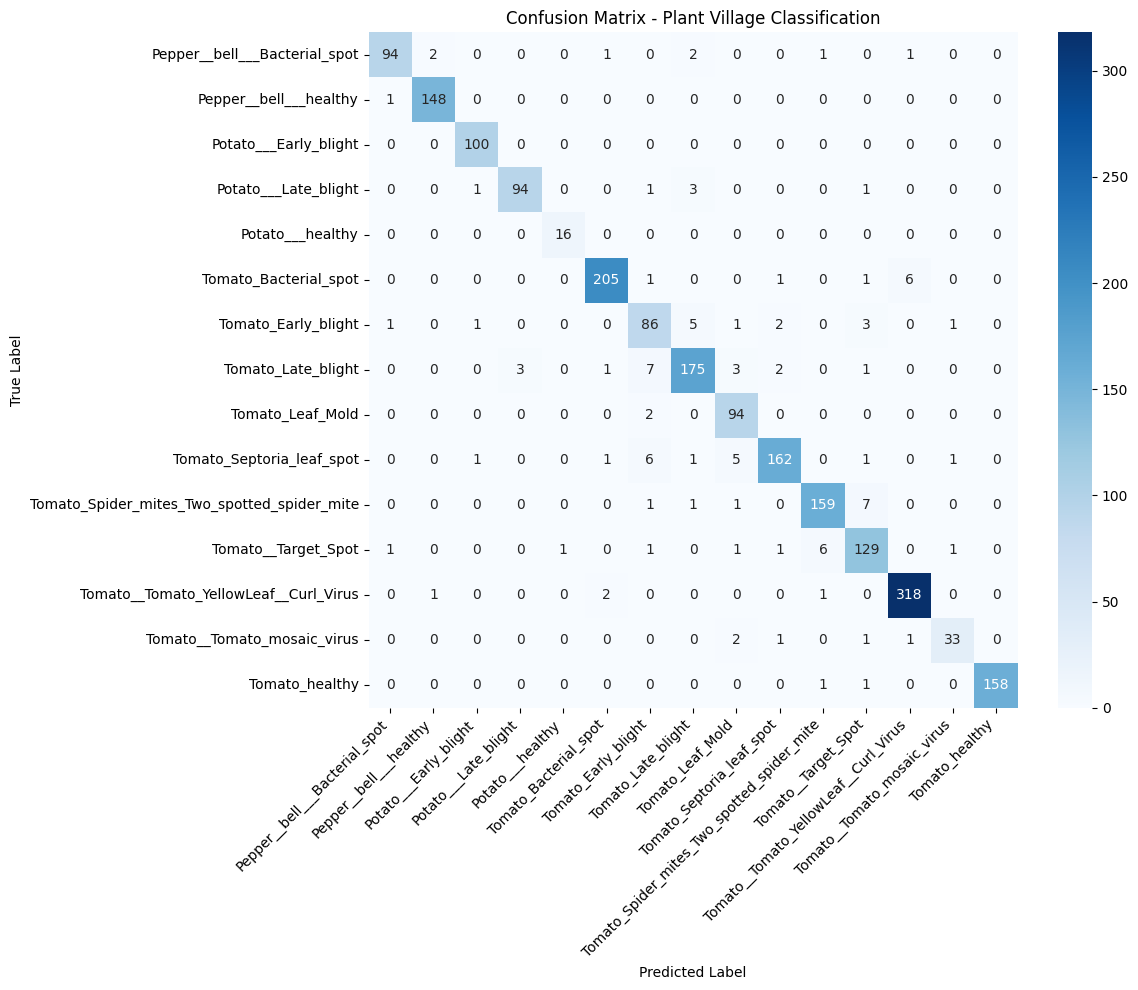


分類報告：
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.93      0.95       101
                     Pepper__bell___healthy       0.98      0.99      0.99       149
                      Potato___Early_blight       0.97      1.00      0.99       100
                       Potato___Late_blight       0.97      0.94      0.95       100
                           Potato___healthy       0.94      1.00      0.97        16
                      Tomato_Bacterial_spot       0.98      0.96      0.97       214
                        Tomato_Early_blight       0.82      0.86      0.84       100
                         Tomato_Late_blight       0.94      0.91      0.92       192
                           Tomato_Leaf_Mold       0.88      0.98      0.93        96
                  Tomato_Septoria_leaf_spot       0.96      0.91      0.93       178
Tomato_Spider_mites_Two_spotted_spider_mite       0.95   

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 執行測試集評估並收集預測值
model_ft.eval()
all_preds = []
all_labels = []

print("正在測試集上進行評估...")
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 計算混淆矩陣
class_names = image_datasets['train'].classes
cm = confusion_matrix(all_labels, all_preds)

# 繪製混淆矩陣圖表
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Plant Village Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 輸出分類報告 (F1-score, Precision, Recall)
print("\n分類報告：")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [21]:
# 解凍模型特定層進行微調，讓 layer4 和 fc 層參與訓練
for name, child in model_ft.named_children():
    if name in ['layer4', 'fc']:
        print(f"正在解凍: {name}")
        for param in child.parameters():
            param.requires_grad = True
    else:
        for param in child.parameters():
            param.requires_grad = False

# 設定極小的學習率進行微調
optimizer_fine = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-5)

print("\n開始微調訓練...")
model_ft = train_model(model_ft, criterion, optimizer_fine, num_epochs=3)

正在解凍: layer4
正在解凍: fc

開始微調訓練...
Epoch 0/2
----------


train Phase: 100%|██████████| 258/258 [01:14<00:00,  3.45batch/s, loss=0.121]


train Loss: 0.1363 Acc: 0.9613


val Phase: 100%|██████████| 33/33 [00:07<00:00,  4.13batch/s, loss=0.0211]


val Loss: 0.1172 Acc: 0.9689

Epoch 1/2
----------


...

val Loss: 0.0932 Acc: 0.9733

Epoch 2/2
----------


train Phase: 100%|██████████| 258/258 [01:13<00:00,  3.49batch/s, loss=0.0643]


train Loss: 0.0399 Acc: 0.9944


val Phase: 100%|██████████| 33/33 [00:07<00:00,  4.13batch/s, loss=0.00693]

val Loss: 0.0755 Acc: 0.9776

訓練完成，耗時 4m 9s
最佳驗證集準確度: 0.977648


In [22]:
# 再次執行測試集評估與混淆矩陣
model_ft.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("微調後的分類報告：")
print(classification_report(all_labels, all_preds, target_names=class_names))

微調後的分類報告：
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.95      0.97       101
                     Pepper__bell___healthy       0.99      1.00      0.99       149
                      Potato___Early_blight       1.00      1.00      1.00       100
                       Potato___Late_blight       0.98      0.97      0.97       100
                           Potato___healthy       0.94      1.00      0.97        16
                      Tomato_Bacterial_spot       0.99      0.99      0.99       214
                        Tomato_Early_blight       0.96      0.93      0.94       100
                         Tomato_Late_blight       0.96      0.96      0.96       192
                           Tomato_Leaf_Mold       0.96      0.99      0.97        96
                  Tomato_Septoria_leaf_spot       0.99      0.99      0.99       178
Tomato_Spider_mites_Two_spotted_spider_mite       0.97

In [23]:
import os

save_path = os.path.join(plant_village_path, 'plant_disease_resnet18_finetuned.pth')

torch.save(model_ft.state_dict(), save_path)

print(f"模型權重已成功儲存至: {save_path}")

模型權重已成功儲存至: /content/drive/MyDrive/PlantVillage/plant_disease_resnet18_finetuned.pth


Saving 00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG to 00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG


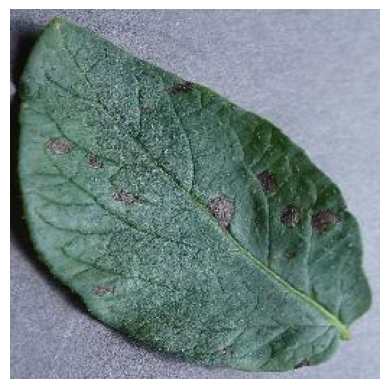

--- 預測結果 ---
檔名: 00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG
判斷類別: Potato___Early_blight
信心度: 97.24%
----------------


In [24]:
import torch
from PIL import Image
from torchvision import transforms
from google.colab import files
import matplotlib.pyplot as plt

inference_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

uploaded = files.upload()

model_ft.eval()
for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    input_tensor = inference_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model_ft(input_tensor)
        _, preds = torch.max(outputs, 1)
        confidence = torch.nn.functional.softmax(outputs, dim=1)[0][preds[0]] * 100

    result_class = class_names[preds[0]]

    print(f"--- 預測結果 ---")
    print(f"檔名: {filename}")
    print(f"判斷類別: {result_class}")
    print(f"信心度: {confidence:.2f}%")
    print("----------------")